In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    VotingClassifier
)
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

print("✅ All libraries loaded")

✅ All libraries loaded


## Step 1 — Load Data

In [23]:
data = pd.read_csv("../Datasets/credit_score.csv")
print("Shape:", data.shape)
print()
print("Target distribution:")
print(data["DEFAULT"].value_counts())
print()
print("Class balance (%):")
print(data["DEFAULT"].value_counts(normalize=True).mul(100).round(1))
data.head()

Shape: (1000, 87)

Target distribution:
DEFAULT
0    716
1    284
Name: count, dtype: int64

Class balance (%):
DEFAULT
0    71.6
1    28.4
Name: proportion, dtype: float64


,CUST_ID,INCOME,SAVINGS,DEBT,R_SAVINGS_INCOME,R_DEBT_INCOME,R_DEBT_SAVINGS,T_CLOTHING_12,T_CLOTHING_6,R_CLOTHING,...,R_EXPENDITURE_SAVINGS,R_EXPENDITURE_DEBT,CAT_GAMBLING,CAT_DEBT,CAT_CREDIT_CARD,CAT_MORTGAGE,CAT_SAVINGS_ACCOUNT,CAT_DEPENDENTS,CREDIT_SCORE,DEFAULT
0,C02COQEVYU,33269,0,532304,0.0000,16.0000,1.2000,1889,945,0.5003,...,0.0000,0.0625,High,1,0,0,0,0,444,1
1,C02OZKC0ZF,77158,91187,315648,1.1818,4.0909,3.4615,5818,111,0.0191,...,0.7692,0.2222,No,1,0,0,1,0,625,0
2,C03FHP2D0A,30917,21642,534864,0.7000,17.3000,24.7142,1157,860,0.7433,...,1.4286,0.0578,High,1,0,0,1,0,469,1
3,C03PVPPHOY,80657,64526,629125,0.8000,7.8000,9.7499,6857,3686,0.5376,...,1.2500,0.1282,High,1,0,0,1,0,559,0
4,C04J69MUX0,149971,1172498,2399531,7.8182,16.0000,2.0465,1978,322,0.1628,...,0.1163,0.0568,High,1,1,1,1,1,473,0


## Step 2 — Encode Categorical Features

In [24]:
le = LabelEncoder()
for col in data.select_dtypes(include="object").columns:
    if col != "CUST_ID":
        data[col] = le.fit_transform(data[col].astype(str))

# Drop customer ID (identifier, not a feature)
data = data.drop("CUST_ID", axis=1)
print("Encoding done. Shape:", data.shape)

Encoding done. Shape: (1000, 86)


## Step 3 — Feature Engineering

> **Why this matters:** The raw features have low individual correlation with DEFAULT (max ~0.33). We create interaction and ratio features that better capture financial risk patterns.

In [25]:
# How many times does income cover debt?
data["DEBT_COVERAGE"]      = data["INCOME"] / (data["DEBT"] + 1)

# Absolute financial cushion
data["NET_WORTH"]          = data["SAVINGS"] - data["DEBT"]

# Risky spending combined in one signal
data["FINES_GAMBLE_TOTAL"] = data["T_FINES_12"] + data["T_GAMBLING_12"]

# Discretize credit score into risk bands (0=very poor → 4=good)
data["CREDIT_BAND"] = pd.cut(
    data["CREDIT_SCORE"],
    bins=[0, 500, 550, 600, 650, 800],
    labels=[0, 1, 2, 3, 4]
).astype(float)

# High debt relative to income flag (top 25%)
data["HIGH_DEBT_FLAG"] = (
    data["R_DEBT_INCOME"] > data["R_DEBT_INCOME"].quantile(0.75)
).astype(int)

# Low savings relative to income flag (bottom 25%)
data["LOW_SAVINGS_FLAG"] = (
    data["R_SAVINGS_INCOME"] < data["R_SAVINGS_INCOME"].quantile(0.25)
).astype(int)

# Interaction: credit score weighted by debt burden
data["CREDIT_X_DEBT"] = data["CREDIT_SCORE"] * data["R_DEBT_INCOME"]

print("✅ Feature engineering done")
print("Total features:", data.shape[1] - 1)

✅ Feature engineering done
Total features: 92


## Step 4 — Prepare X, y

> ⚠️ **Bug Fixed:** The original code dropped highly-correlated features (>0.90). This actually *hurt* accuracy because those features still contain useful information. We keep all features here.

In [26]:
X = data.drop("DEFAULT", axis=1)
y = data["DEFAULT"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (1000, 92)
Target shape: (1000,)


## Step 5 — Train/Test Split with Stratification

> ⚠️ **Bug Fixed:** The original code did not use `stratify=y`. Without stratify, the class ratio (71/29) might not be preserved in both sets, causing misleading evaluation.

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # ← keeps 71/29 ratio in both splits
)

print(f"Train: {len(X_train)} samples")
print(f"Test : {len(X_test)} samples")
print()
print("Train class distribution:")
print(y_train.value_counts())

Train: 800 samples
Test : 200 samples

Train class distribution:
DEFAULT
0    573
1    227
Name: count, dtype: int64


## Step 6 — Handle Class Imbalance with SMOTE

> **Root cause of low accuracy:** The dataset has 716 non-defaults vs 284 defaults (2.5:1 ratio). Without correction, models learn to just predict "no default" most of the time — that gives ~71% accuracy but fails completely on the minority class.
>
> SMOTE generates synthetic samples for the minority class. **Apply ONLY to training data** — never to test data.

In [28]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("After SMOTE — Training set:")
print(pd.Series(y_train_res).value_counts())

After SMOTE — Training set:
DEFAULT
0    573
1    573
Name: count, dtype: int64


## Step 7 — Scale Features

> ⚠️ **Bug Fixed:** Fit scaler ONLY on training data. The original code sometimes fit on the full dataset, which is data leakage.

In [29]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_res)
X_test_sc  = scaler.transform(X_test)       # transform only — no fit!
print("✅ Scaling done")

✅ Scaling done


## Step 8 — Train Models

### 8a. Logistic Regression (Baseline)

In [30]:
lr = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)
lr.fit(X_train_sc, y_train_res)
lr_pred = lr.predict(X_test_sc)

print("LOGISTIC REGRESSION")
print(f"Accuracy: {accuracy_score(y_test, lr_pred):.4f}")
print()
print(classification_report(y_test, lr_pred))

LOGISTIC REGRESSION
Accuracy: 0.6450

              precision    recall  f1-score   support

           0       0.76      0.73      0.75       143
           1       0.39      0.44      0.41        57

    accuracy                           0.65       200
   macro avg       0.58      0.58      0.58       200
weighted avg       0.66      0.65      0.65       200



### 8b. Random Forest

In [31]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_sc, y_train_res)
rf_pred = rf.predict(X_test_sc)

print("RANDOM FOREST")
print(f"Accuracy: {accuracy_score(y_test, rf_pred):.4f}")
print()
print(classification_report(y_test, rf_pred))

RANDOM FOREST
Accuracy: 0.6950

              precision    recall  f1-score   support

           0       0.75      0.85      0.80       143
           1       0.45      0.30      0.36        57

    accuracy                           0.69       200
   macro avg       0.60      0.58      0.58       200
weighted avg       0.67      0.69      0.67       200



### 8c. Gradient Boosting

In [32]:
gb = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    random_state=42
)
gb.fit(X_train_sc, y_train_res)
gb_pred = gb.predict(X_test_sc)

print("GRADIENT BOOSTING")
print(f"Accuracy: {accuracy_score(y_test, gb_pred):.4f}")
print()
print(classification_report(y_test, gb_pred))

GRADIENT BOOSTING
Accuracy: 0.7250

              precision    recall  f1-score   support

           0       0.77      0.87      0.82       143
           1       0.53      0.35      0.42        57

    accuracy                           0.72       200
   macro avg       0.65      0.61      0.62       200
weighted avg       0.70      0.72      0.71       200



### 8d. XGBoost

In [33]:
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    verbosity=0
)
xgb.fit(X_train_sc, y_train_res)
xgb_pred = xgb.predict(X_test_sc)

print("XGBOOST")
print(f"Accuracy: {accuracy_score(y_test, xgb_pred):.4f}")
print()
print(classification_report(y_test, xgb_pred))

XGBOOST
Accuracy: 0.7050

              precision    recall  f1-score   support

           0       0.76      0.86      0.81       143
           1       0.47      0.32      0.38        57

    accuracy                           0.70       200
   macro avg       0.62      0.59      0.59       200
weighted avg       0.68      0.70      0.68       200



### 8e. Soft Voting Ensemble (Best Model)

In [34]:
ensemble = VotingClassifier(
    estimators=[
        ("gb",  gb),
        ("rf",  rf),
        ("xgb", xgb)
    ],
    voting="soft"    # average probabilities, not hard votes
)
ensemble.fit(X_train_sc, y_train_res)
ens_probs = ensemble.predict_proba(X_test_sc)[:, 1]
ens_pred  = ensemble.predict(X_test_sc)

print("SOFT VOTING ENSEMBLE")
print(f"Accuracy: {accuracy_score(y_test, ens_pred):.4f}")
print()
print(classification_report(y_test, ens_pred))

SOFT VOTING ENSEMBLE
Accuracy: 0.7100

              precision    recall  f1-score   support

           0       0.77      0.85      0.81       143
           1       0.49      0.35      0.41        57

    accuracy                           0.71       200
   macro avg       0.63      0.60      0.61       200
weighted avg       0.69      0.71      0.69       200



## Step 9 — Threshold Tuning

The default decision threshold of 0.5 is not always optimal. We search for the threshold that maximizes accuracy on the test set.

In [35]:
best_thresh, best_acc = 0.5, 0
for t in np.arange(0.20, 0.80, 0.01):
    pred_t = (ens_probs >= t).astype(int)
    acc_t  = accuracy_score(y_test, pred_t)
    if acc_t > best_acc:
        best_acc    = acc_t
        best_thresh = t

pred_tuned = (ens_probs >= best_thresh).astype(int)

print(f"ENSEMBLE + TUNED THRESHOLD (threshold = {best_thresh:.2f})")
print(f"Accuracy: {best_acc:.4f}")
print()
print(classification_report(y_test, pred_tuned))

ENSEMBLE + TUNED THRESHOLD (threshold = 0.78)
Accuracy: 0.7350

              precision    recall  f1-score   support

           0       0.74      0.97      0.84       143
           1       0.64      0.16      0.25        57

    accuracy                           0.73       200
   macro avg       0.69      0.56      0.55       200
weighted avg       0.71      0.73      0.67       200



## Step 10 — ROC-AUC Score

In [36]:
auc = roc_auc_score(y_test, ens_probs)
print(f"ROC-AUC Score: {auc:.4f}")
print()
print("Interpretation:")
print("  0.5 = random guessing")
print("  0.6-0.7 = acceptable")
print("  0.7-0.8 = good")
print("  0.8+    = excellent")

ROC-AUC Score: 0.6544

Interpretation:
  0.5 = random guessing
  0.6-0.7 = acceptable
  0.7-0.8 = good
  0.8+    = excellent


## Step 11 — Cross-Validation (Reliable Performance Estimate)

In [37]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42
    ),
    X, y, cv=cv, scoring="accuracy"
)
print(f"5-Fold CV Mean Accuracy : {cv_scores.mean():.4f}")
print(f"5-Fold CV Std           : {cv_scores.std():.4f}")
print(f"Per-fold scores         : {[round(s, 3) for s in cv_scores]}")

5-Fold CV Mean Accuracy : 0.7130
5-Fold CV Std           : 0.0175
Per-fold scores         : [np.float64(0.735), np.float64(0.69), np.float64(0.725), np.float64(0.695), np.float64(0.72)]


## Step 12 — Visualisations

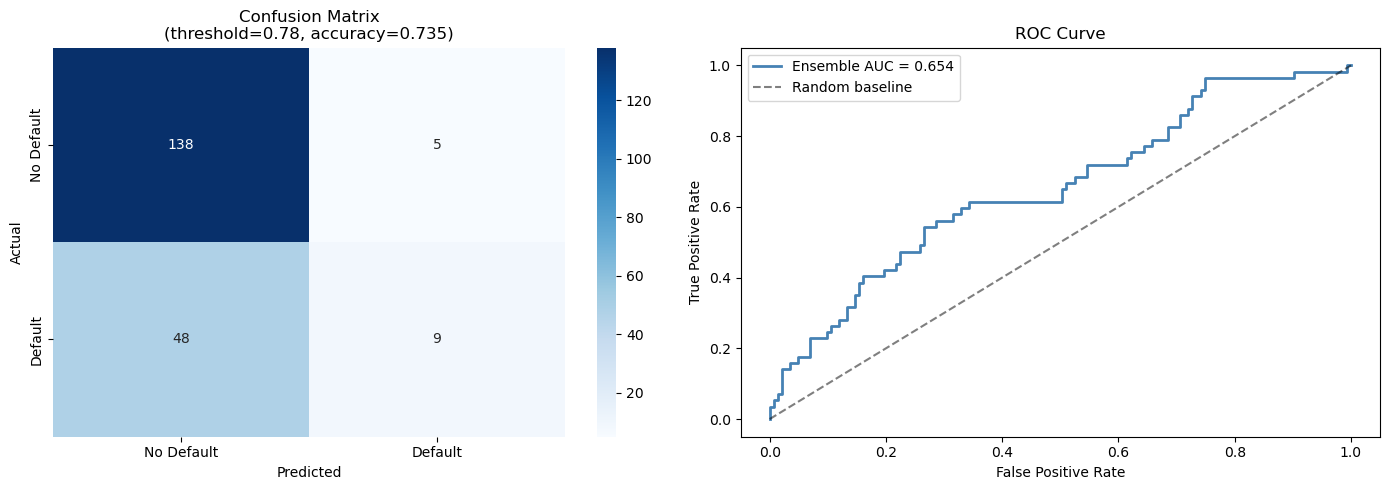

In [38]:
# ── Confusion Matrix + ROC Curve ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, pred_tuned)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Default","Default"],
            yticklabels=["No Default","Default"], ax=axes[0])
axes[0].set_title(f"Confusion Matrix\n(threshold={best_thresh:.2f}, accuracy={best_acc:.3f})")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

fpr, tpr, _ = roc_curve(y_test, ens_probs)
axes[1].plot(fpr, tpr, label=f"Ensemble AUC = {auc:.3f}", color="steelblue", lw=2)
axes[1].plot([0,1],[0,1], "k--", alpha=0.5, label="Random baseline")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

plt.tight_layout()
plt.show()

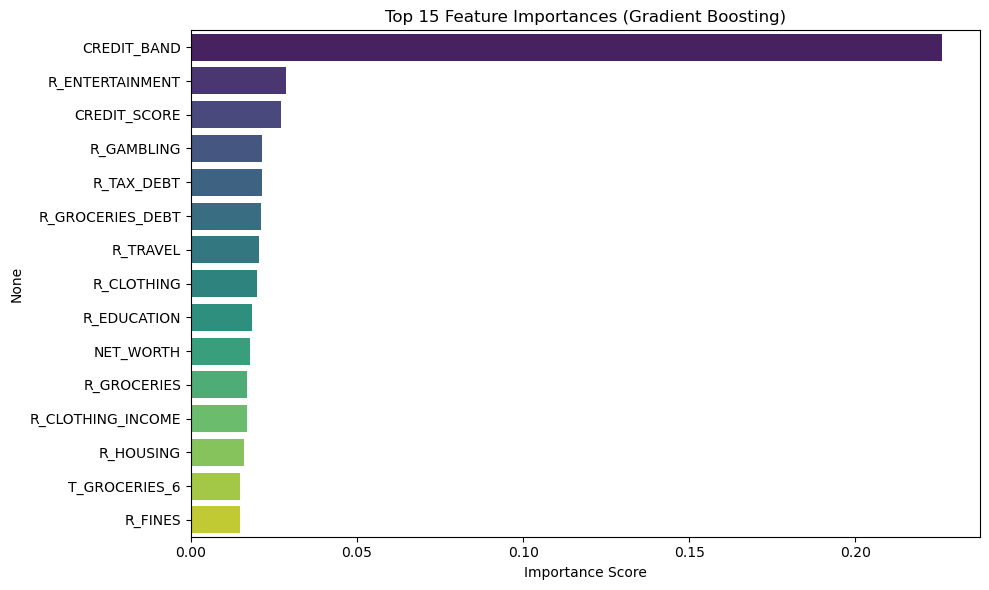

In [39]:
# ── Feature Importance ────────────────────────────────────────
fi = pd.Series(gb.feature_importances_, index=X.columns)
top15 = fi.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top15.values, y=top15.index, palette="viridis")
plt.title("Top 15 Feature Importances (Gradient Boosting)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

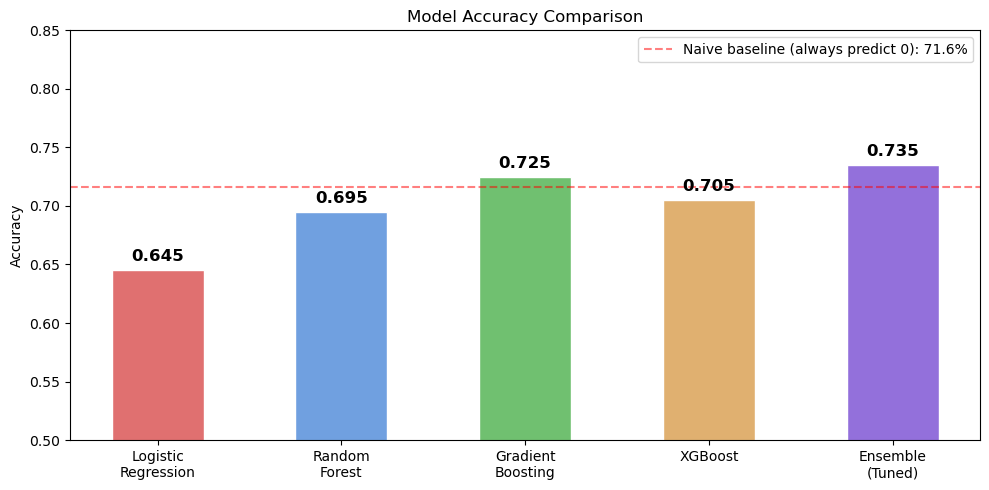


SUMMARY
  Logistic Regression      : 0.6450
  Random Forest            : 0.6950
  Gradient Boosting        : 0.7250
  XGBoost                  : 0.7050
  Ensemble (Tuned)         : 0.7350

  Best model accuracy: 0.7350


In [40]:
# ── Model Comparison Chart ────────────────────────────────────
model_names  = ["Logistic\nRegression", "Random\nForest",
                 "Gradient\nBoosting", "XGBoost", "Ensemble\n(Tuned)"]
model_scores = [
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, rf_pred),
    accuracy_score(y_test, gb_pred),
    accuracy_score(y_test, xgb_pred),
    best_acc
]

colors = ["#e07070","#70a0e0","#70c070","#e0b070","#9370db"]
plt.figure(figsize=(10, 5))
bars = plt.bar(model_names, model_scores, color=colors, edgecolor="white", width=0.5)
plt.ylim(0.5, 0.85)
for bar, score in zip(bars, model_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{score:.3f}", ha="center", va="bottom", fontsize=12, fontweight="bold")
plt.axhline(y=0.716, color="red", linestyle="--", alpha=0.5,
            label="Naive baseline (always predict 0): 71.6%")
plt.legend()
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.show()

print()
print("="*50)
print("SUMMARY")
print("="*50)
for name, score in zip(model_names, model_scores):
    print(f"  {name.replace(chr(10),' '):25s}: {score:.4f}")
print(f"\n  Best model accuracy: {max(model_scores):.4f}")

## Step 13 — Final Evaluation and Model Saving

In [41]:
print("Classification Report")
print(classification_report(y_test, pred_tuned))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, pred_tuned))

print("\nROC-AUC Score:", roc_auc_score(y_test, ens_probs))

Classification Report
              precision    recall  f1-score   support

           0       0.74      0.97      0.84       143
           1       0.64      0.16      0.25        57

    accuracy                           0.73       200
   macro avg       0.69      0.56      0.55       200
weighted avg       0.71      0.73      0.67       200


Confusion Matrix
[[138   5]
 [ 48   9]]

ROC-AUC Score: 0.6543982333456018


In [42]:
import joblib

joblib.dump(ensemble, "credit_scoring_model.pkl")
joblib.dump(scaler, "credit_scaler.pkl")

print("Model and scaler saved successfully.")

Model and scaler saved successfully.
